# S&P 500 Stock Data Analysis (2013-2018)

Analysis of historical stock quotations for S&P 500 companies, including:
- Data quality checks
- Daily returns calculation
- Rolling windows correlation
- Eigenvalue spectrum analysis

## 1. Import Libraries and Load Data

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path


In [20]:
# Load the extracted data
data_path = Path('../data/processed/data.csv')
df = pd.read_csv(data_path)

# Keep ticker names for labels/plots
ticker_cols = df.columns.tolist()

# Core representation from now on: PyTorch tensor
prices_tensor = torch.tensor(df.to_numpy(dtype='float32'), dtype=torch.float32)

# Display basic information
print("Dataset shape:", tuple(prices_tensor.shape), "# (rows=time, cols=tickers)")
print("N. of dates (rows):", prices_tensor.shape[0])
print("N. of tickers/stocks (columns):", prices_tensor.shape[1])
print("\nColumn names (tickers/stocks):")
print(ticker_cols)
print("\nFirst few rows (tensor):")
print(prices_tensor[:5])

Dataset shape: (1260, 640) # (rows=time, cols=tickers)
N. of dates (rows): 1260
N. of tickers/stocks (columns): 640

Column names (tickers/stocks):
['BBY', 'GME', 'RF', 'LIFE', 'CSCO', 'REG', 'TSN', 'TEG', 'KMI', 'LDOS', 'GT', 'DLTR', 'IVZ', 'AMD', 'PFE', 'HSP', 'NLSN', 'R', 'GD', 'JOY', 'EQR', 'GAS', 'PVH', 'XEC', 'MMC', 'FDO', 'CPGX', 'PG', 'CAG', 'AFL', 'LVLT', 'MKC', 'DISH', 'FLIR', 'ALB', 'TMK', 'HUM', 'BLD', 'DVA', 'LM', 'RJF', 'JPM', 'MRK', 'FFIV', 'HIG', 'UAL', 'IRM', 'STT', 'PX', 'FL', 'AEC', 'EOG', 'TMO', 'RAI', 'TEL', 'MGM', 'HON', 'ORCL', 'NFLX', 'SO', 'INTU', 'UTX', 'CB', 'ACN', 'AIV', 'COG', 'HBI', 'CCE', 'CSRA', 'MPC', 'PKG', 'XL', 'CSC', 'SWY', 'AMG', 'NKE', 'LO', 'WDC', 'DISCA', 'BEAM', 'KTF', 'UDR', 'CMCSK', 'STX', 'NCLH', 'VRSK', 'MWV', 'VRSN', 'DNB', 'PLL', 'PBI', 'UBSFY', 'WMT', 'ECL', 'CFN', 'BHI', 'MLM', 'IFF', 'ROK', 'CMG', 'AVP', 'LMT', 'EL', 'CXO', 'TWC', 'HAR', 'TDG', 'SWK', 'USB', 'CERN', 'BF_B', 'CNX', 'ALXN', 'FRX', 'TSO', 'SPG', 'Q', 'WFC', 'STJ', 'DE', '

## 2. Data Quality Checks and Cleaning

This dataset is already cleaned with:
- Survival bias removed
- Ticker changes accounted for
- Stock splits/reverse splits handled

We'll verify data quality and set a minimum threshold for quotations per stock.

In [21]:
# Check for missing values with tensor ops
missing_per_col = torch.isnan(prices_tensor).sum(dim=0)
total_missing = int(missing_per_col.sum().item())
n_cells = prices_tensor.numel()
missing_pct = (total_missing / n_cells) * 100

print("Missing values per column:")
for ticker, n_missing in zip(ticker_cols, missing_per_col.tolist()):
    print(f"{ticker}: {int(n_missing)}")

print(f"\nTotal missing values: {total_missing}")
print(f"Missing percentage: {missing_pct:.2f}%")

Missing values per column:
BBY: 2
GME: 462
RF: 275
LIFE: 1260
CSCO: 2
REG: 1032
TSN: 2
TEG: 672
KMI: 2
LDOS: 1112
GT: 2
DLTR: 2
IVZ: 2
AMD: 884
PFE: 2
HSP: 626
NLSN: 108
R: 176
GD: 2
JOY: 586
EQR: 2
GAS: 418
PVH: 2
XEC: 338
MMC: 2
FDO: 668
CPGX: 1028
PG: 2
CAG: 2
AFL: 275
LVLT: 523
MKC: 2
DISH: 1032
FLIR: 2
ALB: 843
TMK: 2
HUM: 2
BLD: 1237
DVA: 2
LM: 292
RJF: 1032
JPM: 2
MRK: 2
FFIV: 2
HIG: 2
UAL: 654
IRM: 2
STT: 2
PX: 2
FL: 800
AEC: 987
EOG: 2
TMO: 2
RAI: 151
TEL: 2
MGM: 1115
HON: 275
ORCL: 2
NFLX: 2
SO: 2
INTU: 2
UTX: 2
CB: 2
ACN: 2
AIV: 2
COG: 2
HBI: 527
CCE: 441
CSRA: 696
MPC: 275
PKG: 1115
XL: 2
CSC: 566
SWY: 776
AMG: 360
NKE: 2
LO: 684
WDC: 2
DISCA: 2
BEAM: 965
KTF: 986
UDR: 779
CMCSK: 1208
STX: 2
NCLH: 1180
VRSK: 676
MWV: 670
VRSN: 2
DNB: 213
PLL: 629
PBI: 253
UBSFY: 1007
WMT: 2
ECL: 2
CFN: 745
BHI: 165
MLM: 360
IFF: 2
ROK: 2
CMG: 2
AVP: 735
LMT: 275
EL: 2
CXO: 757
TWC: 722
HAR: 244
TDG: 843
SWK: 2
USB: 2
CERN: 2
BF_B: 757
CNX: 483
ALXN: 2
FRX: 923
TSO: 146
SPG: 2
Q: 1208
WFC: 2

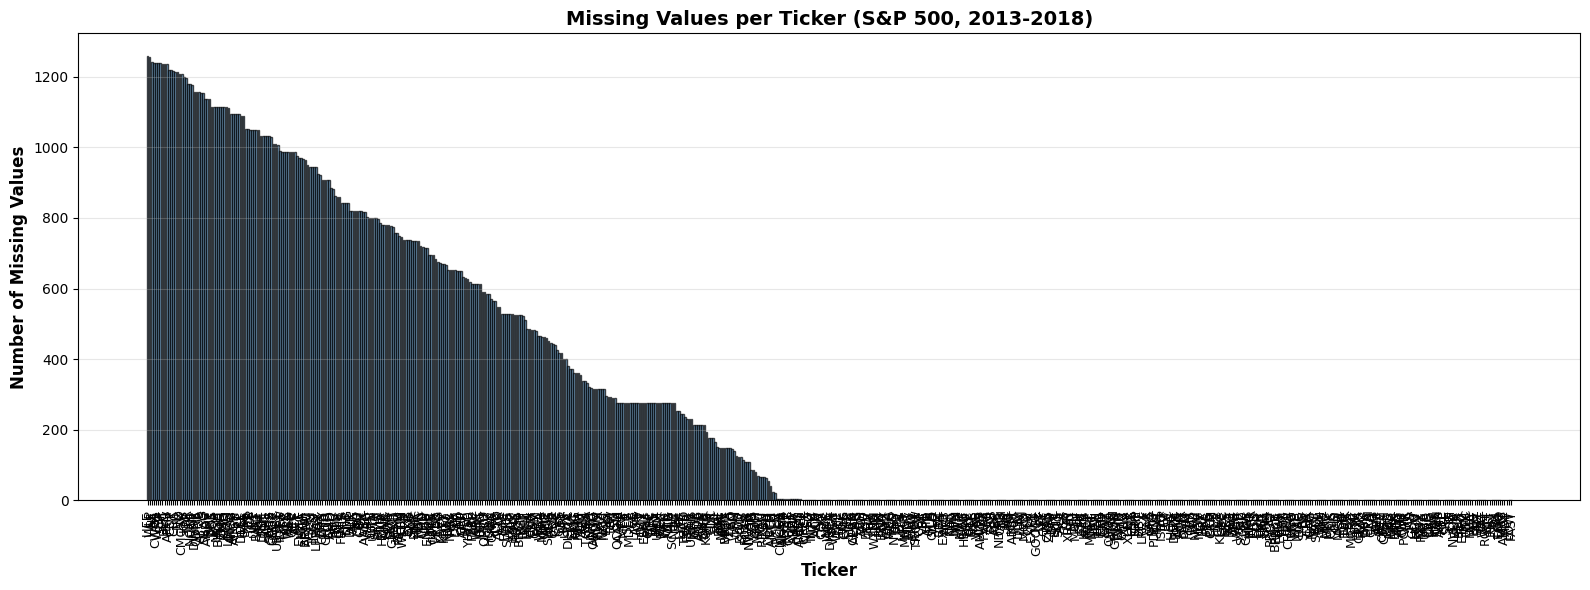

Missing values per ticker (sorted by count):
LIFE: 1260
WLP: 1257
HII: 1241
AA: 1240
CWGL: 1239
WPG: 1238
SYF: 1238
CC: 1237
BLD: 1237
BTI: 1236
APTV: 1220
COP: 1218
X: 1217
CRC: 1214
NU: 1213
Q: 1208
CMCSK: 1208
IQV: 1200
DF: 1196
TPR: 1180
NCLH: 1180
FHN: 1176
DWDP: 1158
CDNS: 1158
A: 1158
APOL: 1154
S: 1154
SBAC: 1138
ANDV: 1138
BHF: 1138
DRE: 1115
AOS: 1115
MGM: 1115
BHGE: 1115
PKG: 1115
ZMH: 1115
RMD: 1115
GCI: 1114
LDOS: 1112
INFO: 1095
ANSS: 1095
ALGN: 1095
HLT: 1095
RE: 1095
DELL: 1090
UAA: 1090
DXC: 1051
IT: 1051
TER: 1048
JCP: 1048
UNS: 1048
BXLT: 1048
ANF: 1048
RJF: 1032
DISH: 1032
REG: 1032
ARE: 1032
SNPS: 1032
CPGX: 1028
CBOE: 1009
INCY: 1009
UBSFY: 1007
IDXX: 990
TW: 987
MTZ: 987
AEC: 987
WPX: 987
ALD: 986
GEC: 986
KTF: 986
ACE: 976
EVHC: 970
MAA: 970
CLF: 966
BEAM: 965
ARNC: 949
SLM: 945
LSI: 945
INCO: 944
LPRAX: 944
IGT: 924
FRX: 923
COTY: 907
MTD: 907
CHTR: 907
COO: 907
AMD: 884
RDC: 881
FTV: 863
BTU: 860
GHC: 860
FBHS: 843
ALB: 843
LNT: 843
TDG: 843
DLR: 821
ALK: 821


In [22]:
# Histogram of missing values per ticker, sorted by bar height
sorted_missing_vals, sorted_idx = torch.sort(missing_per_col, descending=True)
sorted_tickers = [ticker_cols[i] for i in sorted_idx.tolist()]

plt.figure(figsize=(16, 6))
plt.bar(
    range(len(sorted_tickers)),
    sorted_missing_vals.cpu().numpy(),
    color='steelblue',
    edgecolor='black',
    alpha=0.7,
 )
plt.xlabel('Ticker', fontsize=12, fontweight='bold')
plt.ylabel('Number of Missing Values', fontsize=12, fontweight='bold')
plt.title('Missing Values per Ticker (S&P 500, 2013-2018)', fontsize=14, fontweight='bold')
plt.xticks(range(len(sorted_tickers)), sorted_tickers, rotation=90, fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Missing values per ticker (sorted by count):")
for ticker, n_missing in zip(sorted_tickers, sorted_missing_vals.tolist()):
    print(f"{ticker}: {int(n_missing)}")

Quotations per day (across all tickers):
Min: 1
Max: 504
Mean: 490.19
Std: 24.89


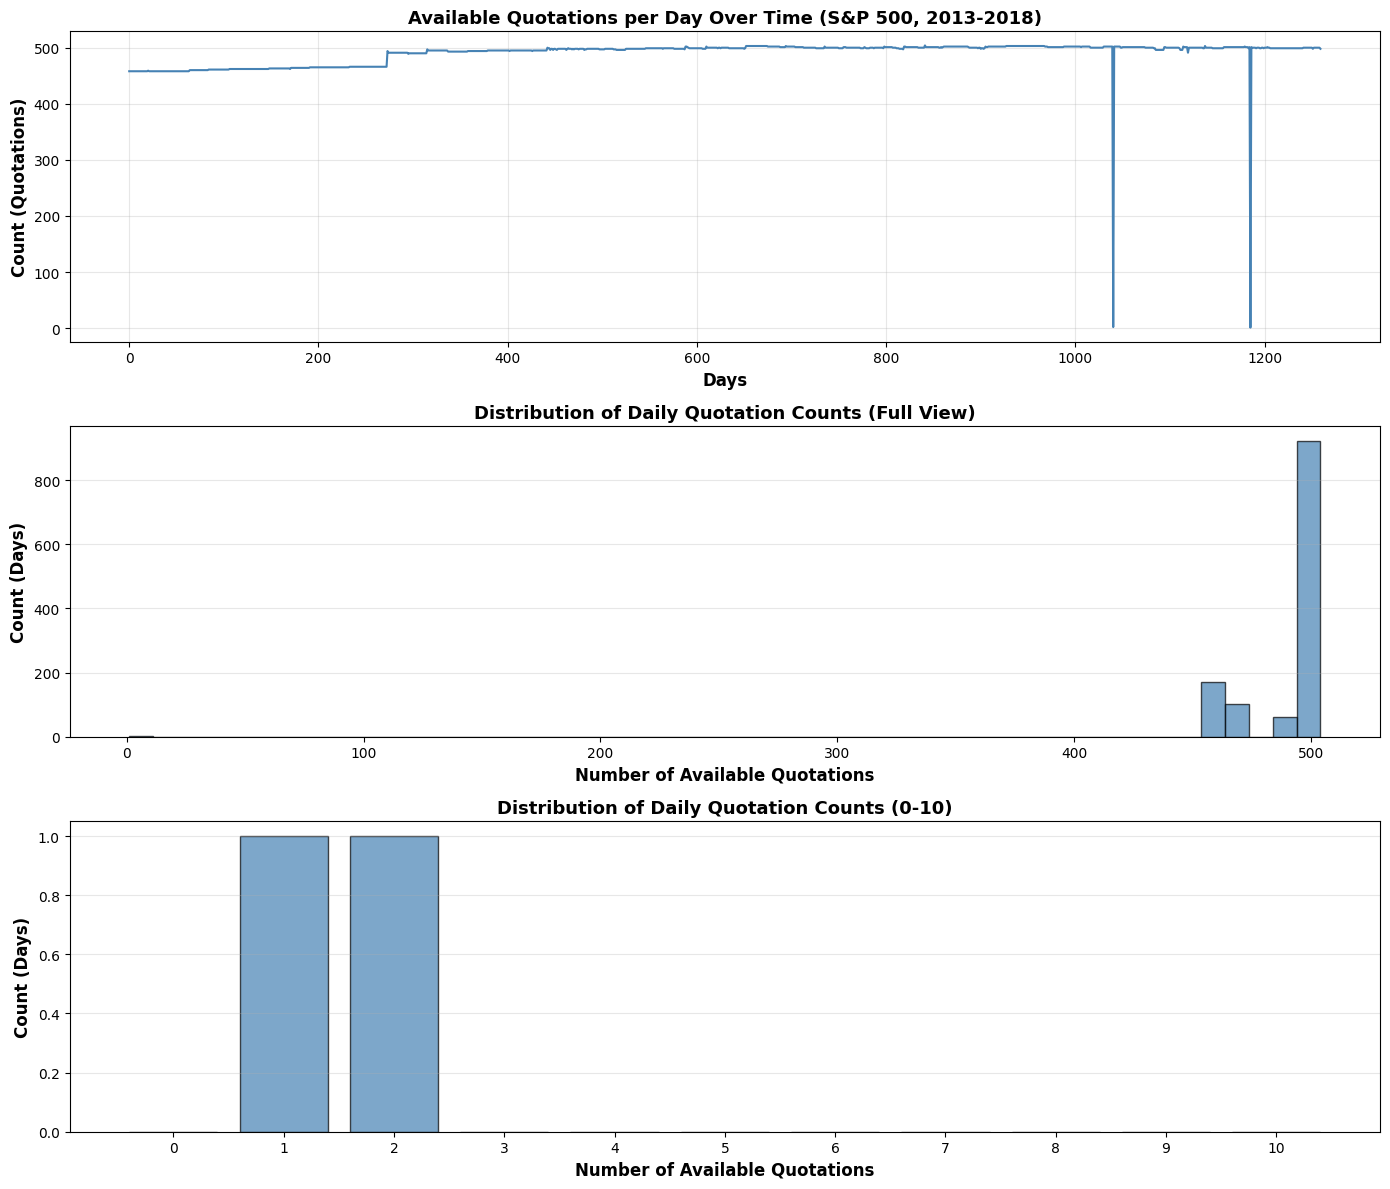

In [23]:
# Count available quotations per day (non-missing values across columns)
quotes_per_day = (~torch.isnan(prices_tensor)).sum(dim=1)

print(f"Quotations per day (across all tickers):") 
print(f"Min: {quotes_per_day.min().item():.0f}")
print(f"Max: {quotes_per_day.max().item():.0f}")
print(f"Mean: {quotes_per_day.float().mean().item():.2f}")
print(f"Std: {quotes_per_day.float().std().item():.2f}")

# Create three subplots stacked vertically
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(14, 12))

quotations_values = quotes_per_day.cpu().numpy()

# Plot 1: Time series of quotations per day
ax0.plot(range(len(quotes_per_day)), quotations_values, linewidth=1.5, color='steelblue')
ax0.set_xlabel('Days', fontsize=12, fontweight='bold')
ax0.set_ylabel('Count (Quotations)', fontsize=12, fontweight='bold')
ax0.set_title('Available Quotations per Day Over Time (S&P 500, 2013-2018)', fontsize=13, fontweight='bold')
ax0.grid(True, alpha=0.3)

# Plot 2: Full histogram
ax1.hist(quotations_values, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Number of Available Quotations', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count (Days)', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Daily Quotation Counts (Full View)', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Plot 3: Absolute frequency histogram for values 0-10
counts = torch.bincount(quotes_per_day.long(), minlength=11)[:11]
ax2.bar(range(11), counts.numpy(), color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Number of Available Quotations', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count (Days)', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Daily Quotation Counts (0-10)', fontsize=13, fontweight='bold')
ax2.set_xticks(range(11))
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Days removed: 2
Days retained: 1258
Filtered dataset shape: (1258, 640)

Filtered days statistics:
Min quotations: 458
Max quotations: 504
Mean quotations: 490.97
Std quotations: 15.49


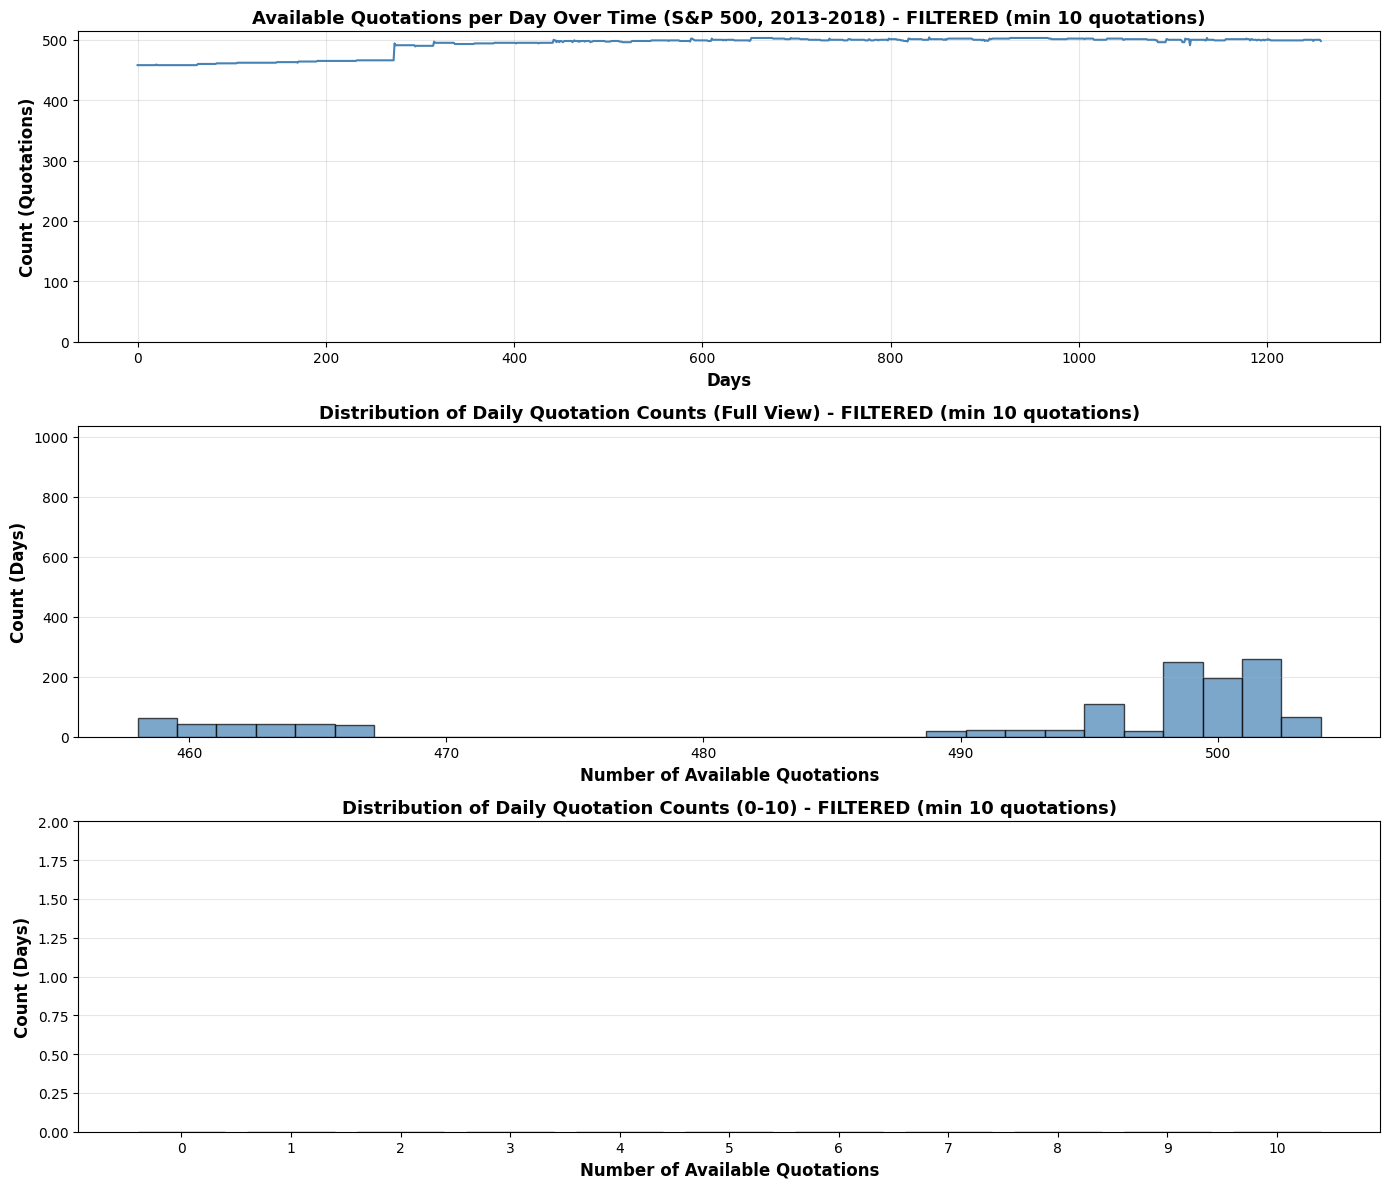

In [24]:
# Filter out days with less than 10 quotations
import numpy as np

MIN_QUOTES_PER_DAY = 10
valid_days_mask = quotes_per_day >= MIN_QUOTES_PER_DAY
valid_day_indices = torch.nonzero(valid_days_mask, as_tuple=False).squeeze(1)

# Create filtered dataset
prices_filtered_tensor = prices_tensor[valid_day_indices, :].clone()
quotes_per_day_filtered = quotes_per_day[valid_day_indices].clone()

print(f"Days removed: {int((~valid_days_mask).sum().item())}")
print(f"Days retained: {int(valid_days_mask.sum().item())}")
print(f"Filtered dataset shape: {tuple(prices_filtered_tensor.shape)}")
print(f"\nFiltered days statistics:")
print(f"Min quotations: {quotes_per_day_filtered.min().item():.0f}")
print(f"Max quotations: {quotes_per_day_filtered.max().item():.0f}")
print(f"Mean quotations: {quotes_per_day_filtered.float().mean().item():.2f}")
print(f"Std quotations: {quotes_per_day_filtered.float().std().item():.2f}")

# Recreate the three plots with filtered data
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(14, 12))

quotations_filtered_values = quotes_per_day_filtered.cpu().numpy()

# Plot 1: Time series of quotations per day (filtered)
ax0.plot(range(len(quotes_per_day_filtered)), quotations_filtered_values, linewidth=1.5, color='steelblue')
ax0.set_xlabel('Days', fontsize=12, fontweight='bold')
ax0.set_ylabel('Count (Quotations)', fontsize=12, fontweight='bold')
ax0.set_title('Available Quotations per Day Over Time (S&P 500, 2013-2018) - FILTERED (min 10 quotations)', fontsize=13, fontweight='bold')
ax0.grid(True, alpha=0.3)

# Plot 2: Full histogram (filtered)
ax1.hist(quotations_filtered_values, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Number of Available Quotations', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count (Days)', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Daily Quotation Counts (Full View) - FILTERED (min 10 quotations)', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Plot 3: Absolute frequency histogram for values 0-10 (filtered)
counts_filtered = torch.bincount(quotes_per_day_filtered.long(), minlength=11)[:11]
ax2.bar(range(11), counts_filtered.numpy(), color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Number of Available Quotations', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count (Days)', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Daily Quotation Counts (0-10) - FILTERED (min 10 quotations)', fontsize=13, fontweight='bold')
ax2.set_xticks(range(11))
ax2.grid(axis='y', alpha=0.3)

# Set y-axis limits to match the unfiltered plots
ax0.set_ylim(0, quotes_per_day.max().item() + 10)

# For histogram, calculate max frequency from unfiltered data
hist_data_all, _ = np.histogram(quotes_per_day.cpu().numpy(), bins=30)
ax1.set_ylim(0, hist_data_all.max() * 1.05)

# For 0-10 bar chart
counts_all_0_10 = torch.bincount(quotes_per_day.long(), minlength=11)[:11]
ax2.set_ylim(0, counts_all_0_10.max().item() + 1)

plt.tight_layout()
plt.show()

In [25]:
# ===== AFTER FILTERING: Recalculate missing values per ticker =====
print("\n" + "="*70)
print("AFTER DAY FILTERING (min 10 quotations per day):")
print("="*70)

# Check for missing values in filtered dataset with tensor ops
missing_per_col_filtered = torch.isnan(prices_filtered_tensor).sum(dim=0)
total_missing_filtered = int(missing_per_col_filtered.sum().item())
n_cells_filtered = prices_filtered_tensor.numel()
missing_pct_filtered = (total_missing_filtered / n_cells_filtered) * 100

print("\nMissing values per ticker (after filtering):")
# Sort by missing values descending
sorted_missing_vals_filtered, sorted_idx_filtered = torch.sort(missing_per_col_filtered, descending=True)
sorted_tickers_filtered = [ticker_cols[i] for i in sorted_idx_filtered.tolist()]

for ticker, n_missing in zip(sorted_tickers_filtered, sorted_missing_vals_filtered.tolist()):
    print(f"{ticker}: {int(n_missing)}")

print(f"\nTotal missing values (filtered): {total_missing_filtered}")
print(f"Missing percentage (filtered): {missing_pct_filtered:.2f}%")

# ===== FILTER TICKERS: Keep only those with 0 missing values =====
print("\n" + "="*70)
print("FILTERING TICKERS: Keep only those with ZERO missing values")
print("="*70)

# Identify tickers with NO missing values
no_missing_mask = missing_per_col_filtered == 0
no_missing_indices = torch.nonzero(no_missing_mask, as_tuple=False).squeeze(1)
tickers_with_complete_data = [ticker_cols[i] for i in no_missing_indices.tolist()]

# Filter the dataset to keep only complete tickers
prices_complete_tensor = prices_filtered_tensor[:, no_missing_indices].clone()

# Validation prints
print(f"\nTickers with NO missing values: {int(no_missing_mask.sum().item())}")
print(f"Tickers removed (with missing values): {int((~no_missing_mask).sum().item())}")
print(f"Final complete dataset shape: {tuple(prices_complete_tensor.shape)}")
print(f"\nTickers with complete data ({len(tickers_with_complete_data)} total):")
print(tickers_with_complete_data)


AFTER DAY FILTERING (min 10 quotations per day):

Missing values per ticker (after filtering):
LIFE: 1258
WLP: 1255
HII: 1239
AA: 1238
CWGL: 1237
WPG: 1236
SYF: 1236
CC: 1235
BLD: 1235
BTI: 1234
APTV: 1218
COP: 1216
X: 1215
CRC: 1212
NU: 1211
Q: 1206
CMCSK: 1206
IQV: 1198
DF: 1194
TPR: 1178
NCLH: 1178
FHN: 1174
DWDP: 1156
CDNS: 1156
A: 1156
APOL: 1152
S: 1152
SBAC: 1136
ANDV: 1136
BHF: 1136
DRE: 1113
AOS: 1113
MGM: 1113
BHGE: 1113
PKG: 1113
ZMH: 1113
RMD: 1113
GCI: 1112
LDOS: 1110
INFO: 1093
ANSS: 1093
ALGN: 1093
HLT: 1093
RE: 1093
DELL: 1088
UAA: 1088
DXC: 1049
IT: 1049
TER: 1046
JCP: 1046
UNS: 1046
BXLT: 1046
ANF: 1046
RJF: 1030
DISH: 1030
REG: 1030
ARE: 1030
SNPS: 1030
CPGX: 1026
CBOE: 1007
INCY: 1007
UBSFY: 1005
IDXX: 988
TW: 985
MTZ: 985
AEC: 985
WPX: 985
ALD: 984
GEC: 984
KTF: 984
ACE: 974
EVHC: 968
MAA: 968
CLF: 964
BEAM: 963
ARNC: 947
SLM: 943
LSI: 943
INCO: 942
LPRAX: 942
IGT: 922
FRX: 921
COTY: 905
MTD: 905
CHTR: 905
COO: 905
AMD: 882
RDC: 879
FTV: 861
BTU: 858
GHC: 858
FBHS

## 3. Saving Filtered Data to CSV

In [26]:
# ===== SAVE FILTERED DATA TO CSV =====
print("SAVING FILTERED DATA TO CSV")

# Convert tensor to DataFrame
df_complete = pd.DataFrame(
    prices_complete_tensor.cpu().numpy(),
    columns=tickers_with_complete_data
)

# Define output path
output_path = Path('../data/processed/filtered_data.csv')

# Save to CSV
df_complete.to_csv(output_path, index=False)

print(f"\nFiltered dataset saved to: {output_path}")
print(f"Shape: {df_complete.shape} (rows=days, columns=tickers)")
print(f"First few rows:\n{df_complete.head()}")

SAVING FILTERED DATA TO CSV

Filtered dataset saved to: ..\data\processed\filtered_data.csv
Shape: (1258, 333) (rows=days, columns=tickers)
First few rows:
         BBY       CSCO        TSN        KMI         GT       DLTR  \
0  14.313087  17.893888  21.696400  30.784206  12.417879  45.185001   
1  14.967250  17.872437  22.184496  30.941988  12.393970  46.110001   
2  15.499302  17.795216  22.213209  31.174509  12.116636  46.480000   
3  16.048800  18.205347  22.328054  31.108076  12.240958  46.000000   
4  16.354074  18.631781  22.557747  30.701162  12.336591  45.470001   

         IVZ        PFE         GD        EQR  ...        XEL         IR  \
0  23.100399  23.138992  61.404850  40.617558  ...  24.195093  38.409443   
1  23.134890  23.155901  61.188030  40.838947  ...  24.203524  37.884186   
2  23.678123  23.409525  60.564674  41.067715  ...  24.532307  38.000908   
3  23.885071  23.730783  61.133823  41.429317  ...  24.641901  38.839863   
4  23.954052  23.773054  61.142860  4